# Spotify Artist Churn Predictor

This notebook documents the exploratory analysis, feature generation, feature selection, and model evaluation for the Spotify Artist Churn Predictor project.

The goal is to predict whether a Spotify user is losing interest in an artist by comparing long-term, medium-term, and short-term listening affinity.

## 1. Project Context

The project uses the Spotify Web API to collect each authorized user's top artists across three time ranges:

- `long_term`: historical listening preference
- `medium_term`: medium-term listening preference
- `short_term`: recent listening preference

Each row in the dataset represents a `user + artist` relationship.

The churn label is defined as:

`churned_artist = 1` if the artist appeared in `long_term` or `medium_term`, but does not appear in `short_term`.

This represents artist listening disengagement risk, not subscription cancellation.

In [11]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('..').resolve()
DATASET_PATH = PROJECT_ROOT / 'data' / 'processed' / 'spotify_artist_churn_dataset.csv'
COMPARISON_PATH = PROJECT_ROOT / 'data' / 'processed' / 'feature_selection_comparison.csv'
METRICS_PATH = PROJECT_ROOT / 'data' / 'processed' / 'model_metrics.json'

df = pd.read_csv(DATASET_PATH)
comparison = pd.read_csv(COMPARISON_PATH)

with open(METRICS_PATH, 'r', encoding='utf-8') as file:
    metrics = json.load(file)

df.head()

,user_id,artist_id,artist_name,long_rank,medium_rank,short_rank,appears_long_term,appears_medium_term,appears_short_term,churned_artist,rank_change_long_to_medium,historical_best_rank,historical_avg_rank,historical_presence_count,is_long_only,is_medium_only,is_present_in_both_historical_windows,long_rank_score,medium_rank_score,historical_affinity_score
0,15e7dff19830,7An4yvF7hDYDolN4m5zKBp,Soda Stereo,1,1,1,1,1,1,0,0,1,1.0,2,0,0,1,1.00,1.00,1.00
1,15e7dff19830,00FQb4jTyendYWaN8pK0wa,Lana Del Rey,2,4,2,1,1,1,0,2,2,3.0,2,0,0,1,0.98,0.94,0.96
2,15e7dff19830,1QOmebWGB6FdFtW7Bo3F0W,Gustavo Cerati,3,3,4,1,1,1,0,0,3,3.0,2,0,0,1,0.96,0.96,0.96
3,15e7dff19830,6Hd3xhv1sj3rlojjvGLkGR,Black Box Recorder,4,2,3,1,1,1,0,-2,2,3.0,2,0,0,1,0.94,0.98,0.96
4,15e7dff19830,1Xyo4u8uXC1ZmMpatF05PJ,The Weeknd,5,18,999,1,1,0,1,13,5,11.5,2,0,0,1,0.92,0.66,0.79


## 2. Dataset Overview

In [12]:
print('Rows:', len(df))
print('Columns:', len(df.columns))
print('\nColumns:')
print(df.columns.tolist())

print('\nUsers collected:', df['user_id'].nunique())
print('Artists collected:', df['artist_id'].nunique())

Rows: 328
Columns: 20

Columns:
['user_id', 'artist_id', 'artist_name', 'long_rank', 'medium_rank', 'short_rank', 'appears_long_term', 'appears_medium_term', 'appears_short_term', 'churned_artist', 'rank_change_long_to_medium', 'historical_best_rank', 'historical_avg_rank', 'historical_presence_count', 'is_long_only', 'is_medium_only', 'is_present_in_both_historical_windows', 'long_rank_score', 'medium_rank_score', 'historical_affinity_score']

Users collected: 5
Artists collected: 247


## 3. Churn Label Balance

churned_artist
1    0.557927
0    0.442073
Name: proportion, dtype: float64

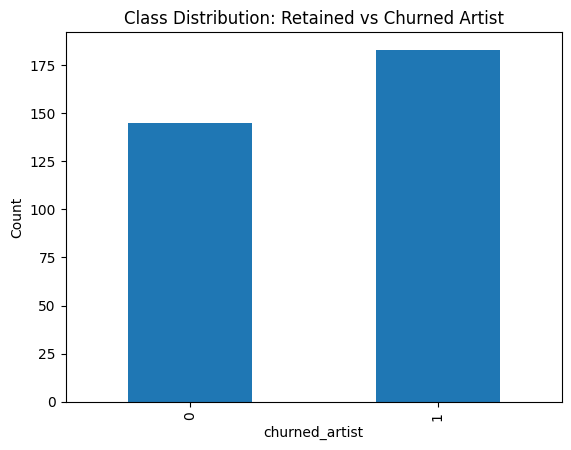

In [13]:
class_balance = df['churned_artist'].value_counts(normalize=True).rename('proportion')
display(class_balance)

df['churned_artist'].value_counts().sort_index().plot(kind='bar')
plt.title('Class Distribution: Retained vs Churned Artist')
plt.xlabel('churned_artist')
plt.ylabel('Count')
plt.show()

## 4. Feature Engineering

The raw Spotify fields are not used directly as the final modeling features. Instead, rankings and appearances across time ranges are transformed into behavioral indicators.

Important engineered features include:

- `medium_rank_score`: normalized score based on medium-term artist rank.
- `historical_affinity_score`: average historical strength of the artist for the user.
- `historical_best_rank`: best rank achieved in long-term or medium-term windows.
- `rank_change_long_to_medium`: change in rank between long-term and medium-term windows.
- `is_long_only`: whether the artist only appeared in the long-term window.
- `appears_medium_term`: whether the artist appeared in the medium-term window.

`short_rank` and `appears_short_term` are not used as model features because they define the target label and would create data leakage.

In [14]:
feature_cols = [
    'appears_long_term',
    'appears_medium_term',
    'rank_change_long_to_medium',
    'historical_best_rank',
    'historical_avg_rank',
    'historical_presence_count',
    'is_long_only',
    'is_medium_only',
    'is_present_in_both_historical_windows',
    'long_rank_score',
    'medium_rank_score',
    'historical_affinity_score',
]

df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
appears_long_term,328.0,0.762195,0.426390,0.00,1.000,1.00,1.0000,1.0
appears_medium_term,328.0,0.762195,0.426390,0.00,1.000,1.00,1.0000,1.0
rank_change_long_to_medium,328.0,475.225610,499.675991,-36.00,0.000,24.00,999.0000,999.0
historical_best_rank,328.0,25.100610,14.452673,1.00,13.000,25.00,37.2500,50.0
historical_avg_rank,328.0,27.722561,13.392425,1.00,17.875,29.00,38.0000,50.0
historical_presence_count,328.0,1.524390,0.500168,1.00,1.000,2.00,2.0000,2.0
is_long_only,328.0,0.237805,0.426390,0.00,0.000,0.00,0.0000,1.0
is_medium_only,328.0,0.237805,0.426390,0.00,0.000,0.00,0.0000,1.0
is_present_in_both_historical_windows,328.0,0.524390,0.500168,0.00,0.000,1.00,1.0000,1.0
long_rank_score,328.0,0.388720,0.333127,0.00,0.020,0.36,0.6800,1.0


## 5. Exploratory Analysis

In [15]:
df.groupby('churned_artist')[['medium_rank_score', 'historical_affinity_score', 'historical_best_rank', 'historical_avg_rank']].mean()

,medium_rank_score,historical_affinity_score,historical_best_rank,historical_avg_rank
churned_artist,,,,
0,0.589517,0.586759,18.600000,21.662069
1,0.229617,0.369508,30.251366,32.524590


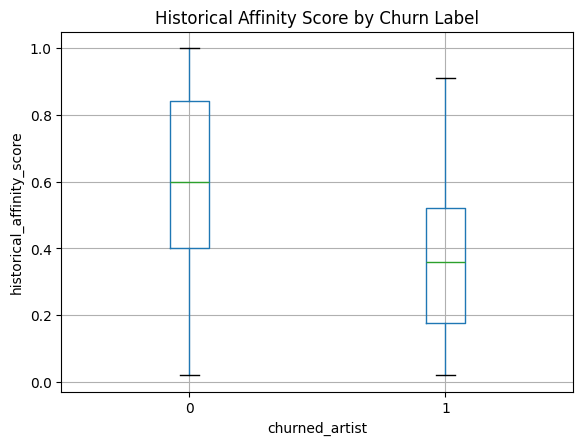

In [16]:
df.boxplot(column='historical_affinity_score', by='churned_artist')
plt.title('Historical Affinity Score by Churn Label')
plt.suptitle('')
plt.xlabel('churned_artist')
plt.ylabel('historical_affinity_score')
plt.show()

## 6. Feature Selection

The project applies four required feature selection approaches:

1. Filter methods: Variance Threshold, ANOVA F-test, and correlation check.
2. Wrapper method: Recursive Feature Elimination using Logistic Regression.
3. Decision Tree feature importance.
4. Random Forest feature importance.

The table below consolidates the rankings and final decision for each feature.

In [17]:
display(comparison[[
    'feature',
    'filter_anova_rank',
    'rfe_selected',
    'dt_rank',
    'rf_rank',
    'selection_score',
    'decision'
]])

,feature,filter_anova_rank,rfe_selected,dt_rank,rf_rank,selection_score,decision
0,medium_rank_score,1,True,1,1,5,Keep
1,historical_affinity_score,4,True,3,5,5,Keep
2,historical_best_rank,6,True,2,4,4,Keep
3,is_long_only,2,True,4,6,4,Keep
4,rank_change_long_to_medium,7,False,5,2,3,Keep
5,historical_avg_rank,5,False,7,3,3,Keep
6,appears_medium_term,3,True,8,7,3,Keep
7,long_rank_score,10,False,6,8,1,Drop
8,historical_presence_count,9,False,8,9,1,Drop
9,appears_long_term,12,False,8,10,1,Drop


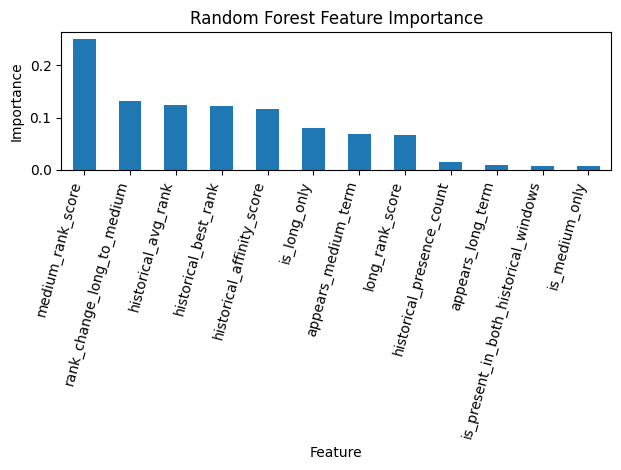

In [18]:
comparison.sort_values('rf_importance', ascending=False).plot(
    x='feature',
    y='rf_importance',
    kind='bar',
    legend=False
)
plt.title('Random Forest Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

## 7. Final Selected Features

In [19]:
print('Selected features:')
for feature in metrics['selected_features']:
    print('-', feature)

Selected features:
- medium_rank_score
- historical_affinity_score
- historical_best_rank
- is_long_only
- rank_change_long_to_medium
- historical_avg_rank
- appears_medium_term


## 8. Model Evaluation

The final model is a Random Forest classifier trained on the selected features. Random Forest was chosen because it is stable, handles non-linear relationships, and also provides feature importance values.

In [20]:
print('Rows:', metrics['rows'])
print('\nTarget distribution:')
print(metrics['target_distribution'])

print('\nTest metrics:')
print(metrics['test_metrics'])

print('\nCross-validation metrics:')
print(metrics['cross_validation_metrics'])

Rows: 328

Target distribution:
{'1': 0.5579268292682927, '0': 0.4420731707317073}

Test metrics:
{'accuracy': 0.7317073170731707, 'precision': 0.7608695652173914, 'recall': 0.7608695652173914, 'f1': 0.7608695652173914}

Cross-validation metrics:
{'accuracy': 0.694965034965035, 'precision': 0.7496970536941431, 'recall': 0.7114114114114114, 'f1': 0.7193351403476764}


## 9. Interpretation: Which Features Matter Most and Why?

The most important features are related to medium-term artist rank and historical affinity. This suggests that churn risk is strongly connected to whether the artist remained relevant in the user's more recent medium-term listening behavior.

- `medium_rank_score` was the strongest feature across several methods. A high medium-term rank means the artist was still relevant recently, reducing churn risk.
- `historical_affinity_score` captures how strongly the artist appeared in the user's historical listening profile.
- `historical_best_rank` indicates how important the artist ever was to the user.
- `is_long_only` helps detect artists that were historically relevant but disappeared from medium-term listening.
- `rank_change_long_to_medium` captures decline or movement in user interest.

Overall, the model shows that churn is not random: artists are more likely to be classified as churned when their presence weakens or disappears between long-term and medium-term listening windows.

## 10. Retention Strategy

If this model were used by a music streaming platform, it could support personalized retention actions. For example:

- If an artist has high churn probability, the platform could recommend a new release from that artist.
- If a user's affinity toward a genre is declining, the system could suggest similar artists or curated playlists.
- If the user historically liked an artist but stopped listening recently, the platform could surface concert announcements, new albums, or related content.

Ethically, the prediction should be treated as a probability, not as a confirmed fact. The model should support recommendations without manipulating or pressuring users.